In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

BASE_PATH = '/content/drive/MyDrive/Cadetx Project/HeavySuppliersWarehouseDatasets/'

Mounted at /content/drive


In [2]:
# 1. Read the three files
lines = pd.read_csv(BASE_PATH + 'sales_orders_lines.csv')
header = pd.read_csv(BASE_PATH + 'sales_orders_header.csv')
products = pd.read_csv(BASE_PATH + 'products.csv')

# 2. Find the column that holds the number of units
qty_col = next(c for c in lines.columns if 'qty' in c.lower() or 'quant' in c.lower())
print("Units column found:", qty_col)

# 3. Keep only Delivered orders and turn the date text into real dates
delivered = header[header['order_status'] == 'Delivered'][['so_id', 'order_date']].copy()
delivered['order_date'] = pd.to_datetime(delivered['order_date'])

# 4. Keep only the lines that belong to Delivered orders
sales = lines.merge(delivered, on='so_id', how='inner')

# 5. Add the product name and category
product_cols = [c for c in ['product_id', 'product_name', 'category'] if c in products.columns]
sales = sales.merge(products[product_cols], on='product_id', how='left')

# 6. Print the checks
print("Delivered orders:", delivered['so_id'].nunique())
print("Delivered lines:", len(sales), "(we expect 117,656)")
print("Delivered units:", int(sales[qty_col].sum()), "(we expect 1,234,939)")
print("Lines with no product name:", sales['product_name'].isna().sum() if 'product_name' in sales.columns else "no product_name column")
print("Date range:", sales['order_date'].min().date(), "to", sales['order_date'].max().date())

Units column found: quantity
Delivered orders: 18033
Delivered lines: 117656 (we expect 117,656)
Delivered units: 1234939 (we expect 1,234,939)
Lines with no product name: 0
Date range: 2019-01-01 to 2024-12-31


In [3]:
# 1. Make a "month" column (the first day of each order's month)
sales['month'] = sales['order_date'].dt.to_period('M').dt.to_timestamp()

# 2. Add up the units for each product in each month
monthly = (sales.groupby(['product_id', 'product_name', 'month'])[qty_col]
                .sum()
                .reset_index()
                .rename(columns={qty_col: 'units_sold'}))

# 3. Print the checks
print("Rows in monthly table:", len(monthly))
print("Products:", monthly['product_id'].nunique())
print("Months:", monthly['month'].nunique())
print("If every product sold every month we would have:", monthly['product_id'].nunique() * monthly['month'].nunique(), "rows")
print("Total units in monthly table:", int(monthly['units_sold'].sum()), "(must equal 1,234,939)")
print()
print(monthly.head(10))

Rows in monthly table: 2160
Products: 30
Months: 72
If every product sold every month we would have: 2160 rows
Total units in monthly table: 1234939 (must equal 1,234,939)

  product_id           product_name      month  units_sold
0       P001  Hydraulic Pump HP-300 2019-01-01         467
1       P001  Hydraulic Pump HP-300 2019-02-01         390
2       P001  Hydraulic Pump HP-300 2019-03-01         612
3       P001  Hydraulic Pump HP-300 2019-04-01         542
4       P001  Hydraulic Pump HP-300 2019-05-01         695
5       P001  Hydraulic Pump HP-300 2019-06-01         645
6       P001  Hydraulic Pump HP-300 2019-07-01         797
7       P001  Hydraulic Pump HP-300 2019-08-01         599
8       P001  Hydraulic Pump HP-300 2019-09-01         515
9       P001  Hydraulic Pump HP-300 2019-10-01         613


In [4]:
# 1. One row per product: total units and average per month
velocity = (monthly.groupby(['product_id', 'product_name'])['units_sold']
                   .agg(total_units='sum', avg_units_per_month='mean')
                   .reset_index())

# 2. Share of all units sold, in percent
velocity['share_pct'] = (velocity['total_units'] / velocity['total_units'].sum() * 100).round(2)
velocity['avg_units_per_month'] = velocity['avg_units_per_month'].round(1)

# 3. Sort from fastest to slowest
velocity = velocity.sort_values('avg_units_per_month', ascending=False).reset_index(drop=True)

# 4. Print the checks
print("Products:", len(velocity))
print("Total units:", int(velocity['total_units'].sum()), "(must equal 1,234,939)")
print("Shares add up to:", round(velocity['share_pct'].sum(), 2), "%")
print()
print(velocity.to_string())

Products: 30
Total units: 1234939 (must equal 1,234,939)
Shares add up to: 99.97 %

   product_id                  product_name  total_units  avg_units_per_month  share_pct
0        P029         Pressure Sensor PS-90        42702                593.1       3.46
1        P010           Turbocharger TB-900        42292                587.4       3.42
2        P007          Hydraulic Hose HH-60        42156                585.5       3.41
3        P011     Hydraulic Cylinder HC-200        42093                584.6       3.41
4        P021          Boom Cylinder BC-400        41864                581.4       3.39
5        P006            Alternator ALT-500        41843                581.2       3.39
6        P016               Radiator RD-250        41770                580.1       3.38
7        P003             Air Filter AF-120        41712                579.3       3.38
8        P030              Fuel Pump FP-350        41595                577.7       3.37
9        P012             

In [5]:
# 1. Make a year column and add up units per product per year
sales['year'] = sales['order_date'].dt.year
yearly = sales.pivot_table(index=['product_id', 'product_name'],
                           columns='year', values=qty_col, aggfunc='sum').reset_index()
yearly.columns.name = None

# 2. Percent change from 2019 to 2024
yearly['change_2019_to_2024_pct'] = ((yearly[2024] / yearly[2019] - 1) * 100).round(1)

# 3. Print the checks
print("Total units across all years:", int(yearly[[2019, 2020, 2021, 2022, 2023, 2024]].sum().sum()), "(must equal 1,234,939)")
print("Units per year (all products):")
print(yearly[[2019, 2020, 2021, 2022, 2023, 2024]].sum())
print()
print(yearly.sort_values('change_2019_to_2024_pct', ascending=False).to_string())

Total units across all years: 1234939 (must equal 1,234,939)
Units per year (all products):
2019    207925
2020    212007
2021    208269
2022    202242
2023    204638
2024    199858
dtype: int64

   product_id                  product_name  2019  2020  2021  2022  2023  2024  change_2019_to_2024_pct
5        P006            Alternator ALT-500  6231  7116  7137  6973  7237  7149                     14.7
23       P024            Track Roller TR-60  6231  6840  6603  6371  6803  6638                      6.5
13       P014  Transmission Assembly TA-800  6434  6989  6805  7015  6543  6788                      5.5
15       P016               Radiator RD-250  6646  7286  6990  7138  6725  6985                      5.1
28       P029         Pressure Sensor PS-90  7108  7145  6961  7300  6717  7471                      5.1
26       P027              O-Ring Set OR-50  6634  6943  7146  6664  6552  6931                      4.5
1        P002       Engine Oil Filter OF-90  6960  6943  7203  6415  

In [6]:
# 1. Add up the first three years and the last three years for each product
yearly['first_3_years'] = yearly[[2019, 2020, 2021]].sum(axis=1)
yearly['last_3_years'] = yearly[[2022, 2023, 2024]].sum(axis=1)

# 2. Percent change between the two blocks
yearly['block_change_pct'] = ((yearly['last_3_years'] / yearly['first_3_years'] - 1) * 100).round(1)

# 3. Print the checks
print("First 3 years total:", int(yearly['first_3_years'].sum()))
print("Last 3 years total:", int(yearly['last_3_years'].sum()))
print("Both together:", int(yearly['first_3_years'].sum() + yearly['last_3_years'].sum()), "(must equal 1,234,939)")
print("Products that grew:", (yearly['block_change_pct'] > 0).sum())
print("Products that fell:", (yearly['block_change_pct'] < 0).sum())
print("Products unchanged:", (yearly['block_change_pct'] == 0).sum())
print()
print(yearly[['product_id', 'product_name', 'first_3_years', 'last_3_years', 'block_change_pct']]
      .sort_values('block_change_pct', ascending=False).to_string())

First 3 years total: 628201
Last 3 years total: 606738
Both together: 1234939 (must equal 1,234,939)
Products that grew: 6
Products that fell: 24
Products unchanged: 0

   product_id                  product_name  first_3_years  last_3_years  block_change_pct
5        P006            Alternator ALT-500          20484         21359               4.3
28       P029         Pressure Sensor PS-90          21214         21488               1.3
25       P026         Grease Cartridge GC-5          20072         20335               1.3
29       P030              Fuel Pump FP-350          20690         20905               1.0
23       P024            Track Roller TR-60          19674         19812               0.7
13       P014  Transmission Assembly TA-800          20228         20346               0.6
15       P016               Radiator RD-250          20922         20848              -0.4
0        P001         Hydraulic Pump HP-300          20732         20572              -0.8
21       P02

In [7]:
# 1. Read the purchase files
po_lines = pd.read_csv(BASE_PATH + 'purchase_orders_lines.csv')
po_header = pd.read_csv(BASE_PATH + 'purchase_orders_header.csv')

# 2. Find the column that holds the number of units
po_qty_col = next(c for c in po_lines.columns if 'qty' in c.lower() or 'quant' in c.lower())
print("Units column found:", po_qty_col)

# 3. Keep only the lines that belong to Received orders
received = po_header[po_header['po_status'] == 'Received'][['po_id']]
bought_lines = po_lines.merge(received, on='po_id', how='inner')

# 4. Print the checks
print("Received orders:", received['po_id'].nunique(), "(we expect 21,630)")
print("Received lines:", len(bought_lines), "(we expect 140,077)")
print("Received units:", int(bought_lines[po_qty_col].sum()), "(we expect 22,387,123)")
print("Products in the lines:", bought_lines['product_id'].nunique())

Units column found: quantity
Received orders: 21630 (we expect 21,630)
Received lines: 140077 (we expect 140,077)
Received units: 22387123 (we expect 22,387,123)
Products in the lines: 30


In [8]:
# 1. Add up units bought for each product
bought = (bought_lines.groupby('product_id')[po_qty_col].sum()
                      .reset_index()
                      .rename(columns={po_qty_col: 'units_bought'}))

# 2. Put units sold and units bought side by side
compare = (velocity[['product_id', 'product_name', 'total_units']]
           .rename(columns={'total_units': 'units_sold'})
           .merge(bought, on='product_id', how='left'))

# 3. Units bought for every 1 unit sold, and each product's share of all units bought
compare['bought_per_1_sold'] = (compare['units_bought'] / compare['units_sold']).round(1)
compare['share_of_bought_pct'] = (compare['units_bought'] / compare['units_bought'].sum() * 100).round(2)
compare = compare.sort_values('bought_per_1_sold', ascending=False).reset_index(drop=True)

# 4. Print the checks
print("Products:", len(compare))
print("Products with no purchases:", compare['units_bought'].isna().sum())
print("Total sold:", int(compare['units_sold'].sum()), "(must equal 1,234,939)")
print("Total bought:", int(compare['units_bought'].sum()), "(must equal 22,387,123)")
print("Overall bought per 1 sold:", round(compare['units_bought'].sum() / compare['units_sold'].sum(), 1))
print("Lowest product:", compare['bought_per_1_sold'].min(), " Highest product:", compare['bought_per_1_sold'].max())
print()
print(compare.to_string())

Products: 30
Products with no purchases: 0
Total sold: 1234939 (must equal 1,234,939)
Total bought: 22387123 (must equal 22,387,123)
Overall bought per 1 sold: 18.1
Lowest product: 17.4  Highest product: 19.2

   product_id                  product_name  units_sold  units_bought  bought_per_1_sold  share_of_bought_pct
0        P024            Track Roller TR-60       39486        757049               19.2                 3.38
1        P005          Fuel Injector FI-220       40480        759066               18.8                 3.39
2        P023             Idler Wheel IW-55       40276        758185               18.8                 3.39
3        P014  Transmission Assembly TA-800       40574        764100               18.8                 3.41
4        P002       Engine Oil Filter OF-90       40917        764701               18.7                 3.42
5        P017                Fan Belt FB-30       40920        761754               18.6                 3.40
6        P013       

In [9]:
# 1. Add the order date to the purchase lines
bought_d = bought_lines.merge(po_header[['po_id', 'order_date']], on='po_id', how='left')
bought_d['order_date'] = pd.to_datetime(bought_d['order_date'])
bought_d['year'] = bought_d['order_date'].dt.year
bought_d['month'] = bought_d['order_date'].dt.to_period('M').dt.to_timestamp()
print("Purchase date range:", bought_d['order_date'].min().date(), "to", bought_d['order_date'].max().date())
print("Total bought:", int(bought_d[po_qty_col].sum()), "(must equal 22,387,123)")

# 2. Test 1: each year, sold and bought side by side
by_year = pd.DataFrame({'units_sold': sales.groupby('year')[qty_col].sum(),
                        'units_bought': bought_d.groupby('year')[po_qty_col].sum()})
by_year['bought_per_1_sold'] = (by_year['units_bought'] / by_year['units_sold']).round(1)
print()
print("TEST 1 - by year")
print(by_year.to_string())

# 3. Test 2: month by month
by_month = pd.DataFrame({'sold': sales.groupby('month')[qty_col].sum(),
                         'bought': bought_d.groupby('month')[po_qty_col].sum()}).dropna()
print()
print("TEST 2 - month by month")
print("Months compared:", len(by_month), "(we expect 72)")
print("Link between monthly sold and monthly bought (-1 to +1):", round(by_month['sold'].corr(by_month['bought']), 2))

# 4. Test 3: product by product, change in sales vs change in buying
sold_p = sales.groupby(['product_id', 'year'])[qty_col].sum().unstack()
bought_p = bought_d.groupby(['product_id', 'year'])[po_qty_col].sum().unstack()
first, last = [2019, 2020, 2021], [2022, 2023, 2024]
chg = pd.DataFrame({
    'sales_change_pct': (sold_p[last].sum(axis=1) / sold_p[first].sum(axis=1) - 1) * 100,
    'buying_change_pct': (bought_p[last].sum(axis=1) / bought_p[first].sum(axis=1) - 1) * 100}).round(1)
print()
print("TEST 3 - product by product")
print("Products compared:", len(chg), "(we expect 30)")
print("Link between sales change and buying change (-1 to +1):", round(chg['sales_change_pct'].corr(chg['buying_change_pct']), 2))
print(chg.sort_values('sales_change_pct').to_string())

Purchase date range: 2019-01-01 to 2024-12-31
Total bought: 22387123 (must equal 22,387,123)

TEST 1 - by year
      units_sold  units_bought  bought_per_1_sold
year                                             
2019      207925       3736316               18.0
2020      212007       3805018               17.9
2021      208269       3759011               18.0
2022      202242       3687415               18.2
2023      204638       3741449               18.3
2024      199858       3657914               18.3

TEST 2 - month by month
Months compared: 72 (we expect 72)
Link between monthly sold and monthly bought (-1 to +1): 0.28

TEST 3 - product by product
Products compared: 30 (we expect 30)
Link between sales change and buying change (-1 to +1): -0.36
            sales_change_pct  buying_change_pct
product_id                                     
P028                    -9.5               -6.2
P025                    -9.0                1.7
P005                    -8.2                2.0

High-sales months: 36  Low-sales months: 36 (together must be 72)
High-sales months - average sold: 18191  average bought: 314089
Low-sales months  - average sold: 16113  average bought: 307775
Buying in high-sales months compared with low-sales months: 2.1 %

Month-to-month moves: 71 (we expect 71)
Moves where sales and buying went the same way: 42
Share of moves in the same way: 59.2 % (a coin flip would give about 50%)


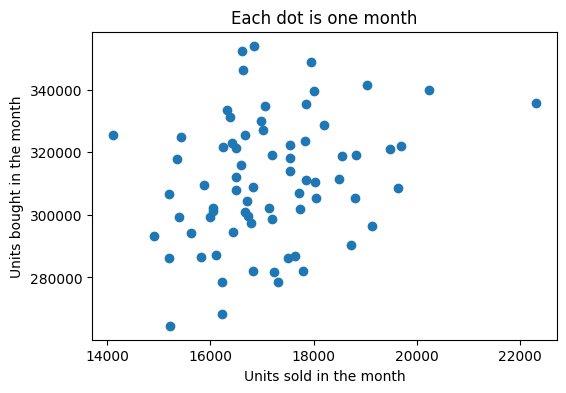

In [10]:
import matplotlib.pyplot as plt

# 1. Split the 72 months into high-sales months and low-sales months
middle = by_month['sold'].median()
high = by_month[by_month['sold'] > middle]
low = by_month[by_month['sold'] <= middle]

print("High-sales months:", len(high), " Low-sales months:", len(low), "(together must be 72)")
print("High-sales months - average sold:", round(high['sold'].mean()), " average bought:", round(high['bought'].mean()))
print("Low-sales months  - average sold:", round(low['sold'].mean()), " average bought:", round(low['bought'].mean()))
print("Buying in high-sales months compared with low-sales months:",
      round((high['bought'].mean() / low['bought'].mean() - 1) * 100, 1), "%")

# 2. Count how often sales and buying move the same way from one month to the next
moves = by_month.sort_index().diff().dropna()
same_way = ((moves['sold'] > 0) == (moves['bought'] > 0)).sum()
print()
print("Month-to-month moves:", len(moves), "(we expect 71)")
print("Moves where sales and buying went the same way:", same_way)
print("Share of moves in the same way:", round(same_way / len(moves) * 100, 1), "% (a coin flip would give about 50%)")

# 3. Picture: one dot per month
plt.figure(figsize=(6, 4))
plt.scatter(by_month['sold'], by_month['bought'])
plt.xlabel('Units sold in the month')
plt.ylabel('Units bought in the month')
plt.title('Each dot is one month')
plt.show()

In [11]:
# 1. Add the branch to the sales lines and to the purchase lines
sales_b = sales.merge(header[['so_id', 'branch_id']], on='so_id', how='left')
bought_b = bought_lines.merge(po_header[['po_id', 'branch_id']], on='po_id', how='left')
print("Sales lines with no branch:", sales_b['branch_id'].isna().sum())
print("Purchase lines with no branch:", bought_b['branch_id'].isna().sum())

# 2. Sold and bought for each branch
by_branch = pd.DataFrame({
    'units_sold': sales_b.groupby('branch_id')[qty_col].sum(),
    'units_bought': bought_b.groupby('branch_id')[po_qty_col].sum()})
by_branch['bought_per_1_sold'] = (by_branch['units_bought'] / by_branch['units_sold']).round(1)

print()
print("Total sold:", int(by_branch['units_sold'].sum()), "(must equal 1,234,939)")
print("Total bought:", int(by_branch['units_bought'].sum()), "(must equal 22,387,123)")
print(by_branch.to_string())

# 3. Sold and bought for each product in each branch (30 x 6 = 180 pairs)
pb = pd.DataFrame({
    'units_sold': sales_b.groupby(['product_id', 'branch_id'])[qty_col].sum(),
    'units_bought': bought_b.groupby(['product_id', 'branch_id'])[po_qty_col].sum()}).reset_index()
pb['bought_per_1_sold'] = (pb['units_bought'] / pb['units_sold']).round(1)

print()
print("Product-branch pairs:", len(pb), "(we expect 180)")
print("Pairs with a missing number:", pb[['units_sold', 'units_bought']].isna().any(axis=1).sum())
print("Lowest ratio:", pb['bought_per_1_sold'].min(),
      " Middle (median):", pb['bought_per_1_sold'].median(),
      " Highest ratio:", pb['bought_per_1_sold'].max())
print()
print("5 highest pairs:")
print(pb.sort_values('bought_per_1_sold', ascending=False).head(5).to_string())

Sales lines with no branch: 0
Purchase lines with no branch: 0

Total sold: 1234939 (must equal 1,234,939)
Total bought: 22387123 (must equal 22,387,123)
           units_sold  units_bought  bought_per_1_sold
branch_id                                             
AHM001         214223       3681090               17.2
CHN001         253921       3797868               15.0
DEL001         185319       3777619               20.4
HYD001         168975       3718428               22.0
KOL001         230868       3661187               15.9
PUN001         181633       3750931               20.7

Product-branch pairs: 180 (we expect 180)
Pairs with a missing number: 0
Lowest ratio: 13.4  Middle (median): 18.55  Highest ratio: 25.5

5 highest pairs:
    product_id branch_id  units_sold  units_bought  bought_per_1_sold
9         P002    HYD001        5413        138227               25.5
140       P024    DEL001        5269        132459               25.1
99        P017    HYD001        5429    

In [12]:
# For each branch, look at its 30 product ratios
summary = pb.groupby('branch_id').agg(
    pairs=('bought_per_1_sold', 'count'),
    lowest=('bought_per_1_sold', 'min'),
    median=('bought_per_1_sold', 'median'),
    highest=('bought_per_1_sold', 'max'),
    pairs_above_20=('bought_per_1_sold', lambda s: int((s > 20).sum())))

print("Total pairs:", int(summary['pairs'].sum()), "(we expect 180)")
print("Pairs above 20 in total:", int(summary['pairs_above_20'].sum()))
print()
print(summary.to_string())

Total pairs: 180 (we expect 180)
Pairs above 20 in total: 65

           pairs  lowest  median  highest  pairs_above_20
branch_id                                                
AHM001        30    15.7   17.20     19.5               0
CHN001        30    13.6   15.05     16.6               0
DEL001        30    18.0   20.35     25.1              19
HYD001        30    19.2   21.70     25.5              27
KOL001        30    13.4   16.10     17.3               0
PUN001        30    18.8   20.70     23.2              19


In [13]:
# 1. For each product, the average monthly sales and how much they swing around it
steady = (monthly.groupby(['product_id', 'product_name'])['units_sold']
                 .agg(avg_per_month='mean', swing='std')
                 .reset_index())
steady['bumpiness_pct'] = (steady['swing'] / steady['avg_per_month'] * 100).round(1)
steady['avg_per_month'] = steady['avg_per_month'].round(1)
steady = steady.sort_values('bumpiness_pct', ascending=False).reset_index(drop=True)

# 2. Print the checks
print("Products:", len(steady), "(we expect 30)")
print("Months per product:", monthly.groupby('product_id')['month'].nunique().unique(), "(we expect [72])")
print("Lowest bumpiness:", steady['bumpiness_pct'].min(), "%",
      " Middle (median):", steady['bumpiness_pct'].median(), "%",
      " Highest bumpiness:", steady['bumpiness_pct'].max(), "%")
print()
print(steady[['product_id', 'product_name', 'avg_per_month', 'bumpiness_pct']].to_string())

Products: 30 (we expect 30)
Months per product: [72] (we expect [72])
Lowest bumpiness: 13.9 %  Middle (median): 17.05 %  Highest bumpiness: 19.1 %

   product_id                  product_name  avg_per_month  bumpiness_pct
0        P005          Fuel Injector FI-220          562.2           19.1
1        P030              Fuel Pump FP-350          577.7           18.6
2        P016               Radiator RD-250          580.1           18.5
3        P025             Cabin Glass CG-20          570.7           18.4
4        P013                Seal Kit SK-15          554.5           18.3
5        P021          Boom Cylinder BC-400          581.4           18.2
6        P026         Grease Cartridge GC-5          561.2           18.0
7        P019           Swing Motor SWM-350          577.0           18.0
8        P008            Bucket Tooth BT-10          570.3           17.7
9        P003             Air Filter AF-120          579.3           17.7
10       P014  Transmission Assembly 

In [14]:
# STEP 1: for each product in each branch, work out the average units sold per month
# (72 = the number of months in the data)
pb['avg_units_per_month'] = (pb['units_sold'] / 72).round(1)

# STEP 2: sort the 180 pairs from slowest to fastest and cut them into 3 equal groups
pb['velocity_group'] = pd.qcut(pb['avg_units_per_month'], 3, labels=['Slow', 'Medium', 'Fast'])

# STEP 3: print the results so we can check them
cuts = pb['avg_units_per_month'].quantile([1/3, 2/3]).round(1)

print("Number of pairs:", len(pb), "(we expect 180)")
print("Slowest pair sells:", pb['avg_units_per_month'].min(), "units per month")
print("Fastest pair sells:", pb['avg_units_per_month'].max(), "units per month")
print("Slow group ends at:", cuts.iloc[0], " Fast group starts at:", cuts.iloc[1])

print()
print("How many pairs in each group (we expect 60 each):")
print(pb['velocity_group'].value_counts().reindex(['Slow', 'Medium', 'Fast']).to_string())

print()
print("How each branch's 30 pairs fall into the groups:")
print(pd.crosstab(pb['branch_id'], pb['velocity_group'])[['Slow', 'Medium', 'Fast']].to_string())

Number of pairs: 180 (we expect 180)
Slowest pair sells: 70.6 units per month
Fastest pair sells: 123.1 units per month
Slow group ends at: 85.8  Fast group starts at: 102.3

How many pairs in each group (we expect 60 each):
velocity_group
Slow      60
Medium    61
Fast      59

How each branch's 30 pairs fall into the groups:
velocity_group  Slow  Medium  Fast
branch_id                         
AHM001             0      24     6
CHN001             0       0    30
DEL001            13      17     0
HYD001            29       1     0
KOL001             0       7    23
PUN001            18      12     0


In [15]:
files = {
    'sales_orders_lines.csv':     ['so_id', 'product_id', 'quantity'],
    'sales_orders_header.csv':    ['so_id', 'order_date', 'order_status', 'branch_id'],
    'purchase_orders_lines.csv':  ['po_id', 'product_id', 'quantity'],
    'purchase_orders_header.csv': ['po_id', 'order_date', 'po_status', 'branch_id'],
    'products.csv':               ['product_id', 'product_name'],
}

for f, cols in files.items():
    df = pd.read_csv(BASE_PATH + f)
    print('\n', f, '-', len(df), 'rows')
    for c in cols:
        line = f'  {c}: empty = {df[c].isna().sum()}'
        if c == 'quantity':
            line += (f', zero = {(df[c] == 0).sum()}, negative = {(df[c] < 0).sum()}, '
                     f'min = {df[c].min()}, max = {df[c].max()}')
        print(line)


 sales_orders_lines.csv - 130402 rows
  so_id: empty = 0
  product_id: empty = 0
  quantity: empty = 0, zero = 0, negative = 0, min = 1, max = 20

 sales_orders_header.csv - 20000 rows
  so_id: empty = 0
  order_date: empty = 0
  order_status: empty = 0
  branch_id: empty = 0

 purchase_orders_lines.csv - 155495 rows
  po_id: empty = 0
  product_id: empty = 0
  quantity: empty = 0, zero = 0, negative = 0, min = 20, max = 300

 purchase_orders_header.csv - 24000 rows
  po_id: empty = 0
  order_date: empty = 0
  po_status: empty = 0
  branch_id: empty = 0

 products.csv - 30 rows
  product_id: empty = 0
  product_name: empty = 0


In [16]:
# bring branch_id in from the raw header file
hdr = pd.read_csv(BASE_PATH + 'sales_orders_header.csv')[['so_id', 'branch_id']]

before = len(sales)
s = sales.merge(hdr, on='so_id', how='left', validate='many_to_one')
print('Rows before:', before, '| after:', len(s), '(should be 117,656 both times)')
print('Lines with no branch:', s['branch_id'].isna().sum())

s['month'] = s['order_date'].dt.to_period('M')
print('Total months in the data:', s['month'].nunique())

# A) months with sales per product
pm = s.groupby('product_id')['month'].nunique()
print('\nProducts:', len(pm))
print('Months with sales per product: min', pm.min(), 'max', pm.max())

# B) months with sales per product-branch pair
pbm = s.groupby(['product_id', 'branch_id'])['month'].nunique()
print('\nProduct-branch pairs:', len(pbm))
print('Months with sales per pair: min', pbm.min(), 'max', pbm.max())
print('Pairs missing at least one month:', (pbm < 72).sum())

Rows before: 117656 | after: 117656 (should be 117,656 both times)
Lines with no branch: 0
Total months in the data: 72

Products: 30
Months with sales per product: min 72 max 72

Product-branch pairs: 180
Months with sales per pair: min 70 max 72
Pairs missing at least one month: 4


In [17]:
all_months = pd.period_range('2019-01', '2024-12', freq='M')
gap_pairs = pbm[pbm < 72].reset_index()

rows = []
for _, r in gap_pairs.iterrows():
    sub = s[(s['product_id'] == r['product_id']) & (s['branch_id'] == r['branch_id'])]
    have = set(sub['month'].unique())
    missing = [str(m) for m in all_months if m not in have]
    total = sub['quantity'].sum()
    rows.append([r['product_id'], r['branch_id'], r['month'], ', '.join(missing),
                 total, round(total / 72, 2), round(total / r['month'], 2)])

out = pd.DataFrame(rows, columns=['product_id', 'branch_id', 'months_with_sales',
                                  'missing_months', 'total_units',
                                  'avg_over_72', 'avg_over_active_months'])
print(out.to_string(index=False))

product_id branch_id  months_with_sales   missing_months  total_units  avg_over_72  avg_over_active_months
      P004    HYD001                 70 2021-01, 2024-06         5148        71.50                   73.54
      P008    KOL001                 71          2023-02         7369       102.35                  103.79
      P018    HYD001                 71          2020-02         5455        75.76                   76.83
      P021    HYD001                 71          2023-08         5999        83.32                   84.49


In [18]:
# Part 1: was the branch busy in the months where this product had no sales?
gaps = [('P004', 'HYD001', '2021-01'), ('P004', 'HYD001', '2024-06'),
        ('P008', 'KOL001', '2023-02'), ('P018', 'HYD001', '2020-02'),
        ('P021', 'HYD001', '2023-08')]

for p, b, m in gaps:
    bm = s[(s['branch_id'] == b) & (s['month'] == pd.Period(m))]
    print(p, b, m, '| branch lines that month (all products):', len(bm),
          '| lines of this product:', (bm['product_id'] == p).sum())

# Part 2: which tables hold the pair-level and product-month numbers?
print()
for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame) and not name.startswith('_') and len(val) in (180, 2160):
        print(name, val.shape, list(val.columns))

P004 HYD001 2021-01 | branch lines that month (all products): 172 | lines of this product: 0
P004 HYD001 2024-06 | branch lines that month (all products): 180 | lines of this product: 0
P008 KOL001 2023-02 | branch lines that month (all products): 246 | lines of this product: 0
P018 HYD001 2020-02 | branch lines that month (all products): 82 | lines of this product: 0
P021 HYD001 2023-08 | branch lines that month (all products): 233 | lines of this product: 0

monthly (2160, 4) ['product_id', 'product_name', 'month', 'units_sold']
pb (180, 7) ['product_id', 'branch_id', 'units_sold', 'units_bought', 'bought_per_1_sold', 'avg_units_per_month', 'velocity_group']


In [19]:
four = [('P004', 'HYD001'), ('P008', 'KOL001'), ('P018', 'HYD001'), ('P021', 'HYD001')]
for p, b in four:
    row = pb[(pb['product_id'] == p) & (pb['branch_id'] == b)].iloc[0]
    print(p, b, '| avg_units_per_month:', row['avg_units_per_month'],
          '| group:', row['velocity_group'])

cuts = pb['avg_units_per_month'].quantile([1/3, 2/3])
print('\nExact equal-thirds cut-offs:', cuts.round(4).tolist())
print('\nGroup sizes:')
print(pb['velocity_group'].value_counts())

P004 HYD001 | avg_units_per_month: 71.5 | group: Slow
P008 KOL001 | avg_units_per_month: 102.3 | group: Medium
P018 HYD001 | avg_units_per_month: 75.8 | group: Slow
P021 HYD001 | avg_units_per_month: 83.3 | group: Slow

Exact equal-thirds cut-offs: [85.8333, 102.3]

Group sizes:
velocity_group
Medium    61
Slow      60
Fast      59
Name: count, dtype: int64


In [20]:
pb2 = pb.copy()
pb2['avg_exact'] = pb2['units_sold'] / 72

# 1) does every saved average equal units_sold / 72?
same = (pb2['avg_exact'].round(1) == pb2['avg_units_per_month']).sum()
print('Pairs where saved average = units_sold / 72:', same, 'of 180')

# 2) labels from the unrounded averages
c1, c2 = pb2['avg_exact'].quantile([1/3, 2/3])
print('Exact cut-offs (unrounded):', round(c1, 4), round(c2, 4))
pb2['group_exact'] = pd.cut(pb2['avg_exact'], [-float('inf'), c1, c2, float('inf')],
                            labels=['Slow', 'Medium', 'Fast'])
print('\nGroup sizes from unrounded averages:')
print(pb2['group_exact'].value_counts())

diff = pb2[pb2['group_exact'].astype(str) != pb2['velocity_group']]
print('\nPairs whose label differs from the saved label:', len(diff))
print(diff[['product_id', 'branch_id', 'avg_exact', 'avg_units_per_month',
            'velocity_group', 'group_exact']].to_string(index=False))

# 3) pairs within 1 unit of a cut-off
near = pb2[((pb2['avg_exact'] - c1).abs() < 1) | ((pb2['avg_exact'] - c2).abs() < 1)]
print('\nPairs within 1 unit of a cut-off:', len(near))

Pairs where saved average = units_sold / 72: 180 of 180
Exact cut-offs (unrounded): 85.8287 102.3287

Group sizes from unrounded averages:
group_exact
Slow      60
Medium    60
Fast      60
Name: count, dtype: int64

Pairs whose label differs from the saved label: 1
product_id branch_id  avg_exact  avg_units_per_month velocity_group group_exact
      P008    KOL001 102.347222                102.3         Medium        Fast

Pairs within 1 unit of a cut-off: 18


In [21]:
pl = pd.read_csv(BASE_PATH + 'purchase_orders_lines.csv')
ph = pd.read_csv(BASE_PATH + 'purchase_orders_header.csv')
ph = ph[ph['po_status'] == 'Received'][['po_id', 'branch_id', 'order_date']]
ph = ph.rename(columns={'branch_id': 'hdr_branch'})

b = pl.merge(ph, on='po_id', how='inner')
print('Received lines:', len(b), '(should be 140,077)')
b['month'] = pd.to_datetime(b['order_date']).dt.to_period('M')
print('Months in the data:', b['month'].nunique())

pm = b.groupby('product_id')['month'].nunique()
print('\nProducts:', len(pm), '| months with purchases per product: min', pm.min(), 'max', pm.max())

pbm = b.groupby(['product_id', 'hdr_branch'])['month'].nunique()
print('\nProduct-branch pairs:', len(pbm), '| months with purchases per pair: min', pbm.min(), 'max', pbm.max())
print('Pairs missing at least one month:', (pbm < 72).sum())

Received lines: 140077 (should be 140,077)
Months in the data: 72

Products: 30 | months with purchases per product: min 72 max 72

Product-branch pairs: 180 | months with purchases per pair: min 71 max 72
Pairs missing at least one month: 3


In [22]:
gp = pbm[pbm < 72].reset_index()
all_months = pd.period_range('2019-01', '2024-12', freq='M')

for _, r in gp.iterrows():
    sub = b[(b['product_id'] == r['product_id']) & (b['hdr_branch'] == r['hdr_branch'])]
    have = set(sub['month'].unique())
    for m in [str(x) for x in all_months if x not in have]:
        bm = b[(b['hdr_branch'] == r['hdr_branch']) & (b['month'] == pd.Period(m))]
        print(r['product_id'], r['hdr_branch'], '| missing month:', m,
              '| branch purchase lines that month (all products):', len(bm),
              '| this product:', (bm['product_id'] == r['product_id']).sum())

P003 KOL001 | missing month: 2021-06 | branch purchase lines that month (all products): 214 | this product: 0
P016 KOL001 | missing month: 2023-08 | branch purchase lines that month (all products): 282 | this product: 0
P023 DEL001 | missing month: 2019-09 | branch purchase lines that month (all products): 210 | this product: 0


In [23]:
ln = pd.read_csv(BASE_PATH + 'sales_orders_lines.csv')
hd = pd.read_csv(BASE_PATH + 'sales_orders_header.csv')

delivered_ids = set(hd.loc[hd['order_status'] == 'Delivered', 'so_id'])
ln = ln[ln['so_id'].isin(delivered_ids)]
print('Delivered lines:', len(ln), '(should be 117,656)')
print('Columns:', list(ln.columns))

# orders where the same product appears on 2 or more lines
rep = ln.groupby(['so_id', 'product_id']).size()
rep = rep[rep > 1]
print('\nOrder-product combos on 2+ lines:', len(rep))
print('Lines involved:', rep.sum())

# are any of those lines exact copies? compare every column except line_number
cols = [c for c in ln.columns if c != 'line_number']
copies = ln.duplicated(subset=cols, keep=False).sum()
print('Lines that are exact copies of another line (ignoring line_number):', copies)

Delivered lines: 117656 (should be 117,656)
Columns: ['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total']

Order-product combos on 2+ lines: 12184
Lines involved: 25422
Lines that are exact copies of another line (ignoring line_number): 1374


In [24]:
# 1) chance that two random lines share a quantity (using the real quantity mix)
p = ln['quantity'].value_counts(normalize=True)
chance = (p ** 2).sum()
print('Chance two random lines share a quantity:', round(chance * 100, 2), '%')

# 2) combos with exactly 2 lines: how often do both lines have the same quantity?
ln['n_lines'] = ln.groupby(['so_id', 'product_id'])['line_number'].transform('size')
two = ln[ln['n_lines'] == 2]
same_qty = two.groupby(['so_id', 'product_id'])['quantity'].nunique() == 1
print('Combos with exactly 2 lines:', len(same_qty))
print('Of those, same quantity:', same_qty.sum(), '=', round(same_qty.mean() * 100, 2), '%')

Chance two random lines share a quantity: 5.0 %
Combos with exactly 2 lines: 11202
Of those, same quantity: 547 = 4.88 %


In [25]:
# Orders where the same product appears on exactly 2 lines
n_lines = sales.groupby(['so_id', 'product_id'])['quantity'].transform('size')
two = sales[n_lines == 2]

# Real rate: how often do the 2 lines have the same quantity?
observed = two.groupby(['so_id', 'product_id'])['quantity'].nunique().eq(1).mean()

# Chance rate: probability two random lines share a quantity
p = sales['quantity'].value_counts(normalize=True)
chance = (p ** 2).sum()

print("Product-in-order combos with exactly 2 lines:", two.groupby(['so_id', 'product_id']).ngroups)
print("Observed same-quantity rate:", round(observed * 100, 2), "%")
print("Chance rate:", round(chance * 100, 2), "%")

Product-in-order combos with exactly 2 lines: 11202
Observed same-quantity rate: 4.88 %
Chance rate: 5.0 %


In [26]:
print('SOLD   orders:', sales['so_id'].nunique(), '| lines:', len(sales), '| units:', sales['quantity'].sum())
print('BOUGHT orders:', b['po_id'].nunique(), '| lines:', len(b), '| units:', b['quantity'].sum())
print('monthly table units_sold total:', monthly['units_sold'].sum())
print('pb table units_sold total:', pb['units_sold'].sum())
print('pb table units_bought total:', pb['units_bought'].sum())

SOLD   orders: 18033 | lines: 117656 | units: 1234939
BOUGHT orders: 21630 | lines: 140077 | units: 22387123
monthly table units_sold total: 1234939
pb table units_sold total: 1234939
pb table units_bought total: 22387123


In [27]:
# Average units per month: monthly table vs straight from raw lines / 72
a = monthly.groupby('product_id')['units_sold'].mean()
raw_avg = sales.groupby('product_id')['quantity'].sum() / 72
print('Products compared:', len(a))
print('Largest difference (product level):', (a - raw_avg.reindex(a.index)).abs().max())

# Same, per product-branch pair: pb table vs raw lines
saved = pb.set_index(['product_id', 'branch_id'])
pair_avg = s.groupby(['product_id', 'branch_id'])['quantity'].sum() / 72
print('Pairs compared:', len(saved))
print('Largest difference (pair level):', (saved['avg_units_per_month'] - pair_avg.reindex(saved.index)).abs().max())

# Bought per 1 sold: pb table vs raw lines
bought = b.groupby(['product_id', 'hdr_branch'])['quantity'].sum()
bought.index.names = ['product_id', 'branch_id']
sold = s.groupby(['product_id', 'branch_id'])['quantity'].sum()
ratio = (bought / sold).reindex(saved.index)
print('Pairs with no ratio computed:', ratio.isna().sum())
print('Largest difference (bought per 1 sold):', (saved['bought_per_1_sold'] - ratio).abs().max())

Products compared: 30
Largest difference (product level): 0.0
Pairs compared: 180
Largest difference (pair level): 0.04999999999999716
Pairs with no ratio computed: 0
Largest difference (bought per 1 sold): 0.049660020744497047


In [28]:
# TREND: first 3 years vs last 3 years, straight from raw lines
yr = s['month'].astype(str).str[:4].astype(int)
first = s[yr <= 2021].groupby('product_id')['quantity'].sum()
last = s[yr >= 2022].groupby('product_id')['quantity'].sum()
chg = (last / first - 1) * 100
print('First 3 years units:', first.sum(), '| last 3 years units:', last.sum())
print('Overall change %:', round((last.sum() / first.sum() - 1) * 100, 1))
print('Products up:', (chg > 0).sum(), '| down:', (chg < 0).sum())
print('Biggest rise:', chg.idxmax(), round(chg.max(), 1), '| biggest fall:', chg.idxmin(), round(chg.min(), 1))

# STEADINESS: product x month table, spread divided by average
piv = s.assign(m=s['month'].astype(str)).pivot_table(index='product_id', columns='m', values='quantity', aggfunc='sum', fill_value=0)
bump = piv.std(axis=1, ddof=1) / piv.mean(axis=1) * 100
print('Months per product:', piv.shape[1])
print('Lowest:', bump.idxmin(), round(bump.min(), 1), '| median:', round(bump.median(), 2), '| highest:', bump.idxmax(), round(bump.max(), 1))

First 3 years units: 628201 | last 3 years units: 606738
Overall change %: -3.4
Products up: 6 | down: 24
Biggest rise: P006 4.3 | biggest fall: P028 -9.5
Months per product: 72
Lowest: P029 13.9 | median: 17.06 | highest: P005 19.1


In [29]:
pb['exact_avg'] = pb['units_sold'] / 72
lo, hi = pb['exact_avg'].quantile([1/3, 2/3])
print('Cut-offs:', round(lo, 4), round(hi, 4))

pb['velocity_group_old'] = pb['velocity_group']
pb['velocity_group'] = pd.cut(pb['exact_avg'], [-float('inf'), lo, hi, float('inf')], labels=['Slow', 'Medium', 'Fast']).astype(str)

print(pb['velocity_group'].value_counts())
changed = pb[pb['velocity_group_old'].astype(str).str.title() != pb['velocity_group']]
print('Labels changed:', len(changed))
print(changed[['product_id', 'branch_id', 'exact_avg', 'velocity_group_old', 'velocity_group']])
print(pd.crosstab(pb['branch_id'], pb['velocity_group']))

Cut-offs: 85.8287 102.3287
velocity_group
Medium    60
Fast      60
Slow      60
Name: count, dtype: int64
Labels changed: 1
   product_id branch_id   exact_avg velocity_group_old velocity_group
46       P008    KOL001  102.347222             Medium           Fast
velocity_group  Fast  Medium  Slow
branch_id                         
AHM001             6      24     0
CHN001            30       0     0
DEL001             0      17    13
HYD001             0       1    29
KOL001            24       6     0
PUN001             0      12    18


In [30]:
# TEST A: largest single line vs average line, per product
g = sales.groupby('product_id')['quantity']
ratio = g.max() / g.mean()
print('Largest line / average line per product: lowest', round(ratio.min(), 2), '| highest', round(ratio.max(), 2))
print('Largest line anywhere:', sales['quantity'].max(), '| average line:', round(sales['quantity'].mean(), 2))

# TEST B: steadiness without each product's single most extreme month
worst_month = piv.sub(piv.mean(axis=1), axis=0).abs().idxmax(axis=1)
trim = pd.Series({p: piv.loc[p].drop(worst_month[p]).std(ddof=1) / piv.loc[p].drop(worst_month[p]).mean() * 100 for p in piv.index})
print('Steadiness, all 72 months:   lowest', round(bump.min(), 1), '| median', round(bump.median(), 2), '| highest', round(bump.max(), 1))
print('Steadiness, worst month out: lowest', round(trim.min(), 1), '| median', round(trim.median(), 2), '| highest', round(trim.max(), 1))
print('Biggest drop for any single product:', round((bump - trim).max(), 2), 'points')

Largest line / average line per product: lowest 1.86 | highest 1.95
Largest line anywhere: 20 | average line: 10.5
Steadiness, all 72 months:   lowest 13.9 | median 17.06 | highest 19.1
Steadiness, worst month out: lowest 13.5 | median 16.44 | highest 18.4
Biggest drop for any single product: 1.26 points


In [31]:
m = s['month'].astype(str)
lines = s.assign(m=m).groupby('m').size()
print('SALES months:', len(lines), '| first:', lines.index[0], '| last:', lines.index[-1])
print('Lines per month: lowest', lines.min(), '| median', int(lines.median()), '| highest', lines.max())
print('First month lines:', lines.iloc[0], '| last month lines:', lines.iloc[-1])

bm = s.assign(m=m).groupby(['branch_id', 'm']).size()
print('Lines per branch-month: lowest', bm.min(), 'at', bm.idxmin(), '| median', int(bm.median()), '| highest', bm.max())

pm = b['month'].astype(str).value_counts().sort_index()
print('PURCHASE months:', len(pm), '| first:', pm.index[0], '| last:', pm.index[-1])
print('Purchase lines per month: lowest', pm.min(), '| median', int(pm.median()), '| highest', pm.max())
print('First month lines:', pm.iloc[0], '| last month lines:', pm.iloc[-1])

SALES months: 72 | first: 2019-01 | last: 2024-12
Lines per month: lowest 1334 | median 1614 | highest 2126
First month lines: 1679 | last month lines: 1488
Lines per branch-month: lowest 82 at ('HYD001', '2020-02') | median 267 | highest 539
PURCHASE months: 72 | first: 2019-01 | last: 2024-12
Purchase lines per month: lowest 1637 | median 1944 | highest 2193
First month lines: 2002 | last month lines: 2082


In [32]:
sl = pd.read_csv(BASE_PATH + 'sales_orders_lines.csv')
sh = pd.read_csv(BASE_PATH + 'sales_orders_header.csv')
pl_raw = pd.read_csv(BASE_PATH + 'purchase_orders_lines.csv')
ph_raw = pd.read_csv(BASE_PATH + 'purchase_orders_header.csv')

fast = pb.loc[pb['exact_avg'].idxmax()]
slow = pb.loc[pb['exact_avg'].idxmin()]
picks = [(fast['product_id'], fast['branch_id']), (slow['product_id'], slow['branch_id']), ('P002', 'HYD001')]

for prod, br in picks:
    so_ok = sh[(sh['order_status'] == 'Delivered') & (sh['branch_id'] == br)]['so_id']
    sold = sl[(sl['so_id'].isin(so_ok)) & (sl['product_id'] == prod)]['quantity'].sum()
    po_ok = ph_raw[(ph_raw['po_status'] == 'Received') & (ph_raw['branch_id'] == br)]['po_id']
    bought = pl_raw[(pl_raw['po_id'].isin(po_ok)) & (pl_raw['product_id'] == prod)]['quantity'].sum()
    row = pb[(pb['product_id'] == prod) & (pb['branch_id'] == br)].iloc[0]
    print(prod, br)
    print('   sold  : raw', sold, '| saved', row['units_sold'])
    print('   bought: raw', bought, '| saved', row['units_bought'])
    print('   avg per month: raw', round(sold / 72, 2), '| saved', row['avg_units_per_month'], '| label', row['velocity_group'])

P023 CHN001
   sold  : raw 8861 | saved 8861
   bought: raw 124901 | saved 124901
   avg per month: raw 123.07 | saved 123.1 | label Fast
P023 HYD001
   sold  : raw 5081 | saved 5081
   bought: raw 119764 | saved 119764
   avg per month: raw 70.57 | saved 70.6 | label Slow
P002 HYD001
   sold  : raw 5413 | saved 5413
   bought: raw 138227 | saved 138227
   avg per month: raw 75.18 | saved 75.2 | label Slow


In [33]:
bb = b.copy()

# Check 6 for purchases: largest line vs average line, per product
g = bb.groupby('product_id')['quantity']
r = g.max() / g.mean()
print('Purchase: largest line / average line per product: lowest', round(r.min(), 2), '| highest', round(r.max(), 2))
print('Largest purchase line:', bb['quantity'].max(), '| average line:', round(bb['quantity'].mean(), 2))

# Check 3 for purchases: repeated product lines inside one purchase order
bb['n_lines'] = bb.groupby(['po_id', 'product_id'])['quantity'].transform('size')
two = bb[bb['n_lines'] == 2]
same = two.groupby(['po_id', 'product_id'])['quantity'].nunique() == 1
p = bb['quantity'].value_counts(normalize=True)
print('Purchase combos with exactly 2 lines:', len(same))
print('Of those, same quantity:', same.sum(), '=', round(same.mean() * 100, 2), '%')
print('Chance rate:', round((p ** 2).sum() * 100, 2), '%')

Purchase: largest line / average line per product: lowest 1.85 | highest 1.92
Largest purchase line: 300 | average line: 159.82
Purchase combos with exactly 2 lines: 13219
Of those, same quantity: 53 = 0.4 %
Chance rate: 0.36 %


In [34]:
sh2 = sh[sh['order_status'] == 'Delivered'][['so_id', 'order_date']].copy()
sh2['order_date'] = pd.to_datetime(sh2['order_date'])
raw = sl.merge(sh2, on='so_id', how='inner')
print('Rows after join:', len(raw), '| units:', raw['quantity'].sum())

for prod in ['P006', 'P028']:
    r = raw[raw['product_id'] == prod]
    first = r[r['order_date'].dt.year <= 2021]['quantity'].sum()
    last = r[r['order_date'].dt.year >= 2022]['quantity'].sum()
    print(prod, '| 2019-21:', first, '| 2022-24:', last, '| change %:', round((last / first - 1) * 100, 1))

months = pd.period_range('2019-01', '2024-12', freq='M')
for prod in ['P029', 'P005']:
    r = raw[raw['product_id'] == prod]
    m = r.groupby(r['order_date'].dt.to_period('M'))['quantity'].sum().reindex(months, fill_value=0)
    print(prod, '| months:', len(m), '| avg per month:', round(m.mean(), 1), '| bumpiness %:', round(m.std(ddof=1) / m.mean() * 100, 1))

Rows after join: 117656 | units: 1234939
P006 | 2019-21: 20484 | 2022-24: 21359 | change %: 4.3
P028 | 2019-21: 21678 | 2022-24: 19614 | change %: -9.5
P029 | months: 72 | avg per month: 593.1 | bumpiness %: 13.9
P005 | months: 72 | avg per month: 562.2 | bumpiness %: 19.1


In [35]:
ids = ['P002','P003','P004','P005','P006','P008','P014','P016','P017','P018','P021','P023','P024','P028','P029']
print(products[products['product_id'].isin(ids)][['product_id', 'product_name']].to_string(index=False))

product_id                 product_name
      P002      Engine Oil Filter OF-90
      P003            Air Filter AF-120
      P004            Track Chain TC-45
      P005         Fuel Injector FI-220
      P006           Alternator ALT-500
      P008           Bucket Tooth BT-10
      P014 Transmission Assembly TA-800
      P016              Radiator RD-250
      P017               Fan Belt FB-30
      P018              Wheel Rim WR-24
      P021         Boom Cylinder BC-400
      P023            Idler Wheel IW-55
      P024           Track Roller TR-60
      P028         Light Assembly LA-18
      P029        Pressure Sensor PS-90
